# Uncertainty Quantification for MoA Classification with Cell Painting

In this notebook, you will learn how to estimate prediction uncertainty using [lightning-uq-box](https://lightning-uq-box.readthedocs.io/en/latest/index.html).

This library supports uncertainty methods for:
- Regression
- Classification
- Segmentation
- Pixel-wise regression

We will use **Monte Carlo (MC) Dropout** and see how uncertainty helps us trust model predictions.

## 0. Setup: Import Libraries

In [1]:
%load_ext autoreload
%autoreload 2

from broad_babel.query import get_mapper
from anndata import AnnData

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from lightning import Trainer
from lightning.pytorch import seed_everything
from lightning.pytorch.loggers import CSVLogger
from lightning_uq_box.uq_methods import MCDropoutClassification
from lightning import LightningDataModule
from lightning_uq_box.datamodules.utils import collate_fn_tensordataset

from lightning_uq_box.models import MLP
from lightning_uq_box.uq_methods import DeterministicClassification
from lightning_uq_box.viz_utils import (
    plot_predictions_classification,
    plot_training_metrics,
)

from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch

from functools import partial

import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import numpy as np
import pandas as pd
import os, gc
import warnings


warnings.filterwarnings("ignore")



/home/ubuntu/scverse_cellpainting_uncertainty/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Preparation

### 1.1 Load Cell Painting Features from JUMP-CP

The [JUMP-Cell Painting Consortium](https://jump-cellpainting.broadinstitute.org/) provides large public Cell Painting datasets.

Here, we use dataset `cpg0016` (overview [here](https://broadinstitute.github.io/jump_hub/explanations/data_description.html)).

We read the feature table directly from cloud storage using `polars`.

In [2]:
index_path="https://cellpainting-gallery.s3.amazonaws.com/cpg0016-jump-assembled/source_all/workspace/profiles_assembled/COMPOUND/v1.0/profiles_var_mad_int_featselect_harmony.parquet"

data = pl.scan_parquet(index_path)
data

### 1.2 Load Compound Metadata from JUMP-MOA

[JUMP-MOA](https://github.com/jump-cellpainting/JUMP-MOA) contains compounds with known mechanisms of action (MoA).

We will keep only Cell Painting samples that match these compounds.

First, download the metadata file:

In [3]:
!wget -O JUMP-MOA_compound_metadata.tsv https://raw.githubusercontent.com/jump-cellpainting/JUMP-MOA/master/JUMP-MOA_compound_metadata.tsv

--2026-07-16 11:31:59--  https://raw.githubusercontent.com/jump-cellpainting/JUMP-MOA/master/JUMP-MOA_compound_metadata.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 25540 (25K) [text/plain]
Saving to: ‘JUMP-MOA_compound_metadata.tsv’

JUMP-MOA_compound_m 100%[===================>]  24.94K  --.-KB/s    in 0.001s  

2026-07-16 11:31:59 (38.8 MB/s) - ‘JUMP-MOA_compound_metadata.tsv’ saved [25540/25540]



Quick check: preview the downloaded MoA metadata table.

In [4]:
df_jump_moa = pd.read_csv("JUMP-MOA_compound_metadata.tsv", sep="\t")
df_jump_moa.head()

,broad_sample,InChIKey,pert_iname,pubchem_cid,moa,pert_type,control_type,smiles,InChI
0,BRD-K80935598-001-01-1,ZYVXTMKTGDARKR-UHFFFAOYSA-N,AZ191,72716071.0,DYRK inhibitor,trt,NaN,COc1cc(N2CCN(C)CC2)ccc1N=c1nc(-c2cn(C)c3cnccc2...,InChI=1S/C24H27N7O/c1-29-10-12-31(13-11-29)17-...
1,BRD-K85776940-001-01-9,ODADKLYLWWCHNB-UHFFFAOYSA-N,delta-Tocotrienol,5282350.0,HMGCR inhibitor,trt,NaN,CC(C)=CCCC(C)=CCCC(C)=CCCC1(C)CCc2cc(O)cc(C)c2O1,InChI=1S/C27H40O2/c1-20(2)10-7-11-21(3)12-8-13...
2,BRD-K25611237-001-02-1,QDBVSOZTVKXUES-UHFFFAOYSA-N,ML324,44143209.0,histone lysine demethylase inhibitor,trt,NaN,CN(C)CCCNC(=O)c1ccc(-c2cc(O)c3ncccc3c2)cc1,InChI=1S/C21H23N3O2/c1-24(2)12-4-11-23-21(26)1...
3,BRD-K66430217-001-03-8,DXZRBHUCOHBAHP-UHFFFAOYSA-N,KH-CB19,44237094.0,CDC inhibitor,trt,NaN,CCOC(=O)c1c(C(C#N)C=N)c2ccc(Cl)c(Cl)c2n1C,InChI=1S/C15H13Cl2N3O2/c1-3-22-15(21)14-11(8(6...
4,BRD-K38627885-001-01-9,DWFWRWOABQRHJO-UHFFFAOYSA-N,APY0201,56927660.0,phosphoinositide dependent kinase inhibitor,trt,NaN,Cc1cccc(C=NN=c2cc(N3CCOCC3)n3[nH]c(-c4ccncc4)c...,InChI=1S/C23H23N7O/c1-17-3-2-4-18(13-17)16-25-...


### 1.3 Match Metadata to Image Features

We now filter Cell Painting profiles to keep only compounds that exist in the JUMP-MOA metadata.

In [5]:
jcp_ids = (
    data.select(pl.col("Metadata_JCP2022")).unique().collect().to_series().sort()
)

# Query in batches to avoid SQL parameter limits, then merge into one dict.
all_jcp_ids = list(dict.fromkeys([*jcp_ids.to_list(), "JCP2022_800002"]))

batch_size = 500
jcp_to_standard_key = {}

for i in range(0, len(all_jcp_ids), batch_size):
    batch_ids = tuple(all_jcp_ids[i : i + batch_size])
    batch_mapper = get_mapper(
        batch_ids,
        input_column="JCP2022",
        output_columns="JCP2022,standard_key",
    )
    jcp_to_standard_key.update(dict(batch_mapper))

# Swap key/value: standard_key -> JCP2022
standard_key_to_jcp = {
    v: k for k, v in jcp_to_standard_key.items() if pd.notna(v)
}

# add jcp key to df_moa
df_jump_moa["JCP2022"] = df_jump_moa["InChIKey"].apply(lambda x : standard_key_to_jcp[x] if x in standard_key_to_jcp.keys() else None)
df_jump_moa = df_jump_moa[~df_jump_moa["JCP2022"].isna()]
df_jump_moa.set_index("JCP2022", inplace=True)

# Query data 
metadata_matched = (
    data
    .filter(pl.col("Metadata_JCP2022").is_in(df_jump_moa.index))
    .collect()
)

metadata_matched.head(), metadata_matched.shape


(shape: (5, 741)
 ┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
 │ Metadata_ ┆ Metadata_ ┆ Metadata_ ┆ Metadata_ ┆ … ┆ X_734     ┆ X_735     ┆ X_736     ┆ X_737    │
 │ Source    ┆ Plate     ┆ Well      ┆ JCP2022   ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
 │ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ f32       ┆ f32       ┆ f32       ┆ f32      │
 │ str       ┆ str       ┆ str       ┆ str       ┆   ┆           ┆           ┆           ┆          │
 ╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
 │ source_2  ┆ 105359780 ┆ K23       ┆ JCP2022_0 ┆ … ┆ -0.711415 ┆ -0.639252 ┆ -0.64338  ┆ -0.46036 │
 │           ┆ 6         ┆           ┆ 33924     ┆   ┆           ┆           ┆           ┆ 8        │
 │ source_2  ┆ 105359780 ┆ K02       ┆ JCP2022_0 ┆ … ┆ 1.123385  ┆ 0.579059  ┆ 1.033897  ┆ 0.989246 │
 │           ┆ 6         ┆           ┆ 33924     ┆   ┆           

### 1.4 Merge Data

Now we merge the metadata and feature table.

Then we store everything in an `AnnData` object.

In [6]:
# merge data
df_jump_moa.rename(
    columns={k : f"Metadata_{k}" for k in df_jump_moa.columns}, inplace=True
)
df_merge = pd.concat([
    metadata_matched.to_pandas().reset_index(drop=True), 
    df_jump_moa.loc[metadata_matched["Metadata_JCP2022"],:].reset_index(drop=True)
], axis=1)

# annotate DMSO to avoid NA value
df_merge.loc[df_merge["Metadata_moa"].isna(), "Metadata_moa"] = "DMSO"

# generate Anndata object
meta_cols, feature_cols = list(), list()
for c in df_merge.columns:
    meta_cols.append(c) if c.startswith("Metadata_") else feature_cols.append(c)
ad_full = AnnData(
    X = df_merge.loc[:, feature_cols],
    obs = df_merge.loc[:, meta_cols]
)
ad_full

AnnData object with n_obs × n_vars = 111803 × 737
    obs: 'Metadata_Source', 'Metadata_Plate', 'Metadata_Well', 'Metadata_JCP2022', 'Metadata_broad_sample', 'Metadata_InChIKey', 'Metadata_pert_iname', 'Metadata_pubchem_cid', 'Metadata_moa', 'Metadata_pert_type', 'Metadata_control_type', 'Metadata_smiles', 'Metadata_InChI'
    layers: None

Clean up large temporary tables to save memory.

In [7]:
del df_merge, df_jump_moa, metadata_matched
gc.collect()

179

## 2. Quick Data Exploration

We pick a few MoA classes and check how much variance each principal component explains.

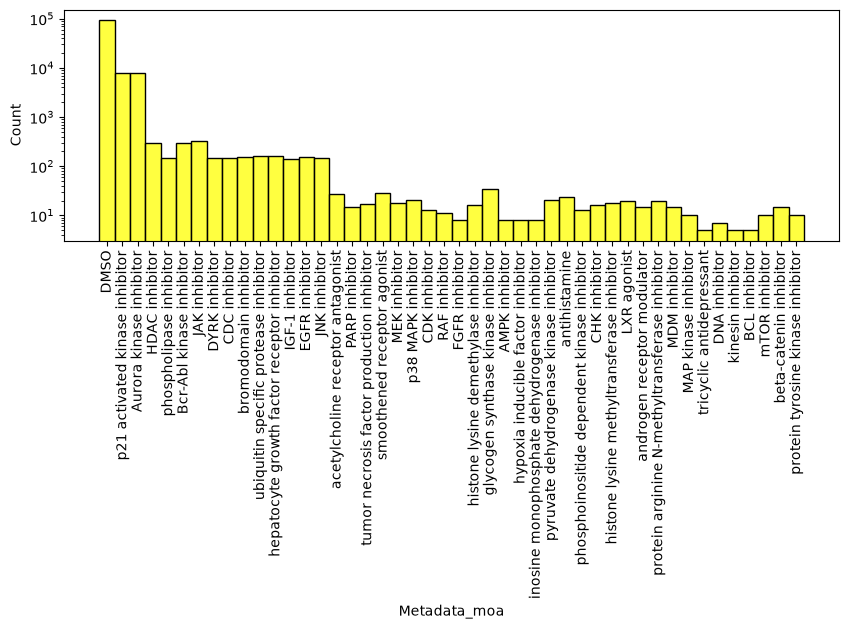

In [8]:
fig, ax = plt.subplots(1, figsize=(10, 3))
sns.histplot(ad_full.obs["Metadata_moa"], ax=ax, color="yellow")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_yscale("log")
plt.show()

Subset data for ['JAK inhibitor', 'HDAC inhibitor', 'DYRK inhibitor'] : View of AnnData object with n_obs × n_vars = 770 × 737
    obs: 'Metadata_Source', 'Metadata_Plate', 'Metadata_Well', 'Metadata_JCP2022', 'Metadata_broad_sample', 'Metadata_InChIKey', 'Metadata_pert_iname', 'Metadata_pubchem_cid', 'Metadata_moa', 'Metadata_pert_type', 'Metadata_control_type', 'Metadata_smiles', 'Metadata_InChI'
    layers: None


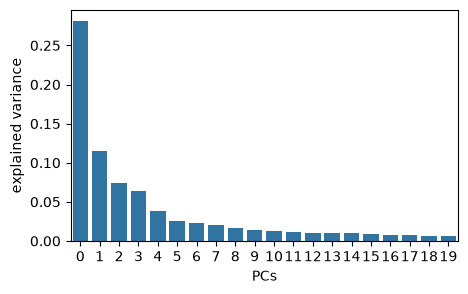

In [9]:
subset_moas = ["JAK inhibitor", "HDAC inhibitor", "DYRK inhibitor"]
ad=ad_full[ad_full.obs["Metadata_moa"].isin(subset_moas)]
print(f"Subset data for {subset_moas} : {ad}")
pca = PCA(n_components=20).fit(ad.X)
fig, ax = plt.subplots(1, figsize=(5, 3))
sns.barplot(pca.explained_variance_ratio_, ax=ax)
ax.set_ylabel("explained variance")
ax.set_xlabel("PCs")
plt.show()

Plot a 2D PCA view to see whether the selected MoA classes separate visually.

<Axes: xlabel='pc1', ylabel='pc2'>

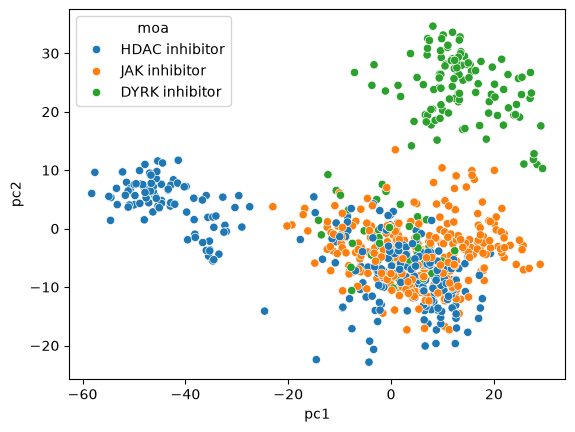

In [10]:
pca = PCA(n_components=2).fit(ad.X)

pc = pca.transform(ad.X)
sns.scatterplot(
    pd.DataFrame(
        {"pc1":pc[:, 0], "pc2":pc[:,1], "moa":ad.obs["Metadata_moa"]}
    ), 
    x="pc1", y="pc2", hue="moa"
)

## 3. Uncertainty Quantification for Multi-Class Classification

We now train classifiers and compare standard predictions vs. uncertainty-aware predictions.

### 3.1 Create a Custom `LightningDataModule`

Because our data is in `AnnData`, we build a small custom data module for PyTorch Lightning.

If this is new to you, see the Lightning DataModule guide [here](https://lightning.ai/docs/pytorch/stable/data/datamodule.html).

In [11]:
# create data module 
class AnnDataModule(LightningDataModule):
    def __init__(self, anndata: AnnData, batch_size: int = 256):
        super().__init__()
        self.batch_size = batch_size
        self.anndata = anndata
        self.setup()
    
    def setup(self, stage: str | None = None):
        self.label_encoder = LabelEncoder()
        label_trainsformed = self.label_encoder.fit_transform(self.anndata.obs["Metadata_moa"])
        
        self.X_train, self.X_valid, self.y_train, self.y_valid = train_test_split(
            torch.tensor(self.anndata.X.toarray().astype(np.float32)),
            torch.tensor(label_trainsformed.astype(np.long)),
            test_size=0.2,
            stratify=
            label_trainsformed,
            random_state=950410
        )
    
    def train_dataloader(self) -> DataLoader:
        return DataLoader(
            TensorDataset(
                torch.tensor(self.X_train), torch.tensor(self.y_train)
            ),
            batch_size=self.batch_size, 
            shuffle=True,
            collate_fn=collate_fn_tensordataset
        )
    
    def val_dataloader(self) -> DataLoader:
        return DataLoader(
            TensorDataset(
                torch.tensor(self.X_valid), torch.tensor(self.y_valid)
            ),
            batch_size=self.batch_size, 
            shuffle=True,
            collate_fn=collate_fn_tensordataset
        )

data_module = AnnDataModule(anndata=ad, batch_size=256)


### 3.2 Define the Neural Network

We use a simple MLP as our classifier.

In [ ]:
network = MLP(
    n_inputs=ad.n_vars,
    n_hidden=[100],
    n_outputs=ad.obs["Metadata_moa"].nunique(),
    dropout_p=0.2, # important for MC Dropout
    activation_fn=nn.ReLU(),
)

### 3.3 Train a Deterministic Baseline

Before adding uncertainty methods, we first train a normal classifier with `DeterministicClassification`.

This gives us a baseline model that predicts classes but does **not** provide uncertainty scores.

In [13]:

classification_module = DeterministicClassification(
    model=network, optimizer=partial(Adam, lr=1e-3), loss_fn=nn.CrossEntropyLoss()
)

log_dir = "./logs/classification_log"
logger = CSVLogger(log_dir)
trainer = Trainer(
    accelerator="gpu",
    max_epochs=300,  # number of epochs we want to train
    logger=logger,  # log training metrics for later evaluation
    log_every_n_steps=1,
    enable_checkpointing=False,
    enable_progress_bar=False,
    default_root_dir=log_dir,
)

trainer.fit(classification_module, data_module)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------------
0 | model         | MLP              | 74.1 K | train | 0    
1 | loss_fn       | CrossEntropyLoss | 0      | train | 0    
2 | train_metrics | MetricCollection | 0   

`Trainer.fit` stopped: `max_epochs=300` reached.


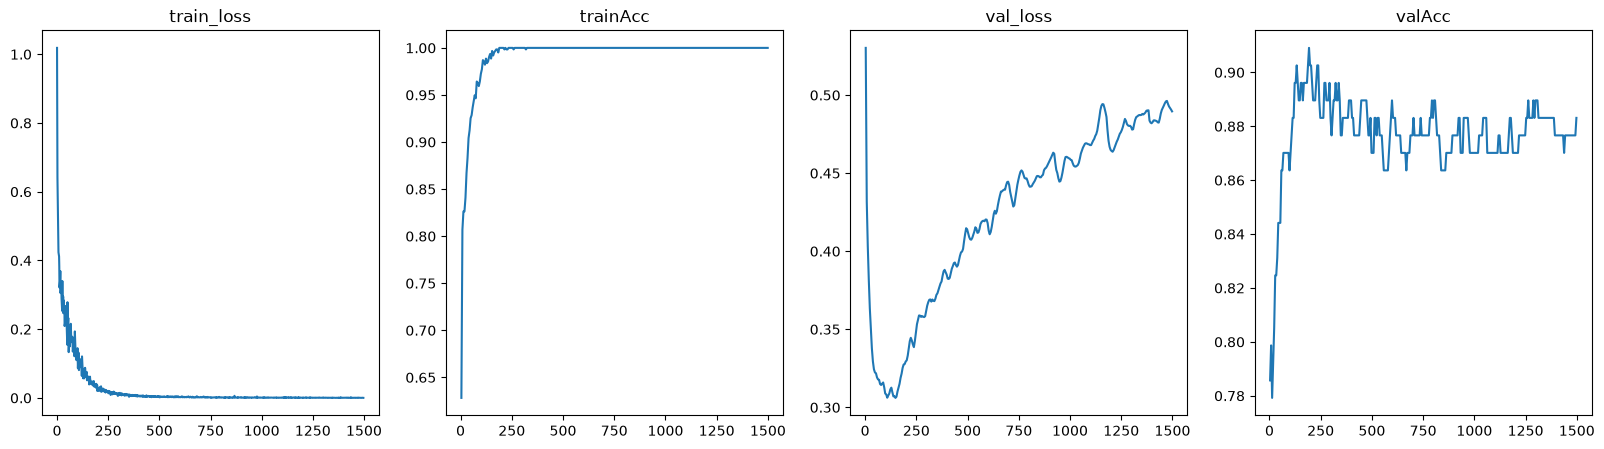

In [14]:
fig = plot_training_metrics(
    os.path.join(log_dir, "lightning_logs"), ["train_loss", "trainAcc", "val_loss", "valAcc"]
)

### 3.4 Train with MC Dropout

MC Dropout keeps dropout active at prediction time and runs multiple stochastic forward passes.

From these repeated predictions, we can estimate uncertainty.

Here we train the same network with MC Dropout.

*Gal, Yarin, and Zoubin Ghahramani. "Dropout as a Bayesian Approximation: Representing Model Uncertainty in Deep Learning." ICML, 2016.*

In [30]:
# Reinitialize a fresh network so MC Dropout starts from new weights
network = MLP(
    n_inputs=ad.n_vars,
    n_hidden=[100],
    n_outputs=ad.obs["Metadata_moa"].nunique(),
    dropout_p=0.2,  # important for MC Dropout
    activation_fn=nn.ReLU(),
)

mc_dropout_module = MCDropoutClassification(
    model=network,
    optimizer=partial(Adam, lr=1e-2),
    loss_fn=nn.CrossEntropyLoss(),
    num_mc_samples=25,
)

log_dir = "./logs/mc_dropout_log"
logger = CSVLogger(log_dir)
trainer = Trainer(
    accelerator="gpu",
    max_epochs=300,  # number of epochs we want to train
    logger=logger,  # log training metrics for later evaluation
    log_every_n_steps=1,
    enable_checkpointing=False,
    enable_progress_bar=False,
    default_root_dir=log_dir,
)

trainer.fit(mc_dropout_module, data_module)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------------
0 | model         | MLP              | 74.1 K | train | 0    
1 | loss_fn       | CrossEntropyLoss | 0      | train | 0    
2 | train_metrics | MetricCollection | 0      | train | 0    
3 | val_metrics   | MetricCollection | 0      | train | 0    
4 | test_metrics  | MetricCollection | 0      | train | 0    
-------------------------------------------------------------------
74.1 K    Trainable params
0         Non-trainable params
74.1 K    Total params
0.296     Total estimated model params size (MB)
19       

`Trainer.fit` stopped: `max_epochs=300` reached.


Compared with the deterministic model, MC Dropout curves can look noisier because dropout stays active during evaluation.

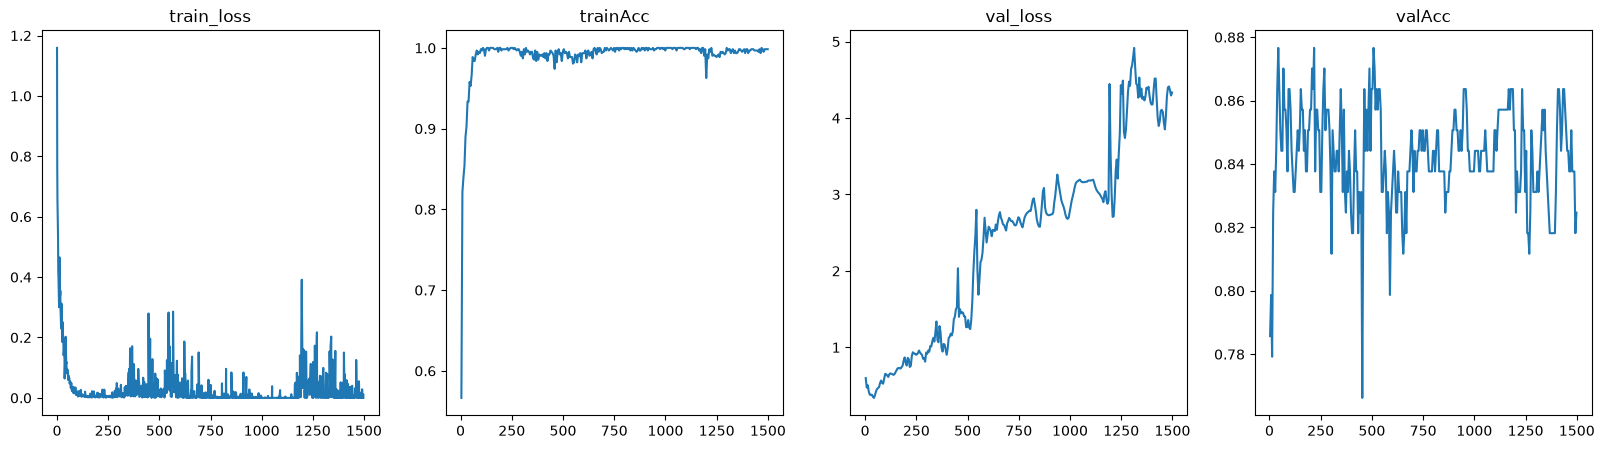

In [31]:
fig = plot_training_metrics(
    os.path.join(log_dir, "lightning_logs"), ["train_loss", "trainAcc", "val_loss", "valAcc"]
)

### 3.5 Inspect Uncertainty

We use `predict_step` to get predictions and uncertainty values.

In [32]:
preds = mc_dropout_module.predict_step(
    data_module.X_valid.to(mc_dropout_module.device)
)

preds["pred_transform"] = data_module.label_encoder.inverse_transform(preds["pred"].argmax(-1)) # logit to label, and number label to human readable labels 
preds["target_transform"] = data_module.label_encoder.inverse_transform(data_module.y_valid)

for k, v in preds.items():
    if type(v) == torch.Tensor:
        preds[k] = v.numpy()

Within each MoA class, correct predictions usually have lower uncertainty than wrong predictions.

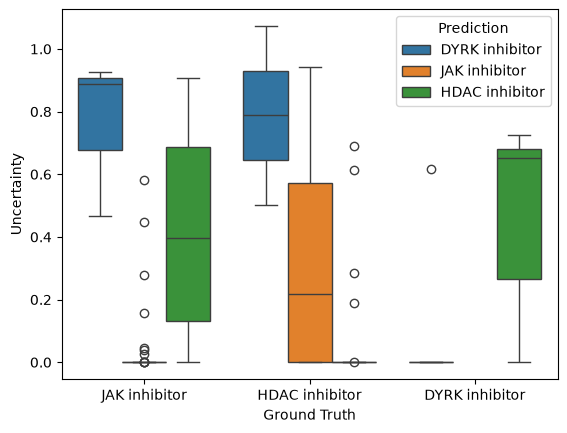

In [33]:
df_eval = pd.DataFrame({
    k: preds[k] for k in ["pred_transform", "target_transform", "pred_uct"]
})

ax = sns.boxplot(
    df_eval, x="target_transform", y="pred_uct", hue="pred_transform"
)
sns.move_legend(ax, loc="upper right", bbox_to_anchor=(1.4, 1))

ax.set_ylabel("Uncertainty")
ax.set_xlabel("Ground Truth")
ax.legend(title="Prediction")

Finally, we plot true labels, predicted labels, and uncertainty on a 2D PCA grid.

You will often see higher uncertainty near class boundaries and in regions where classes overlap.

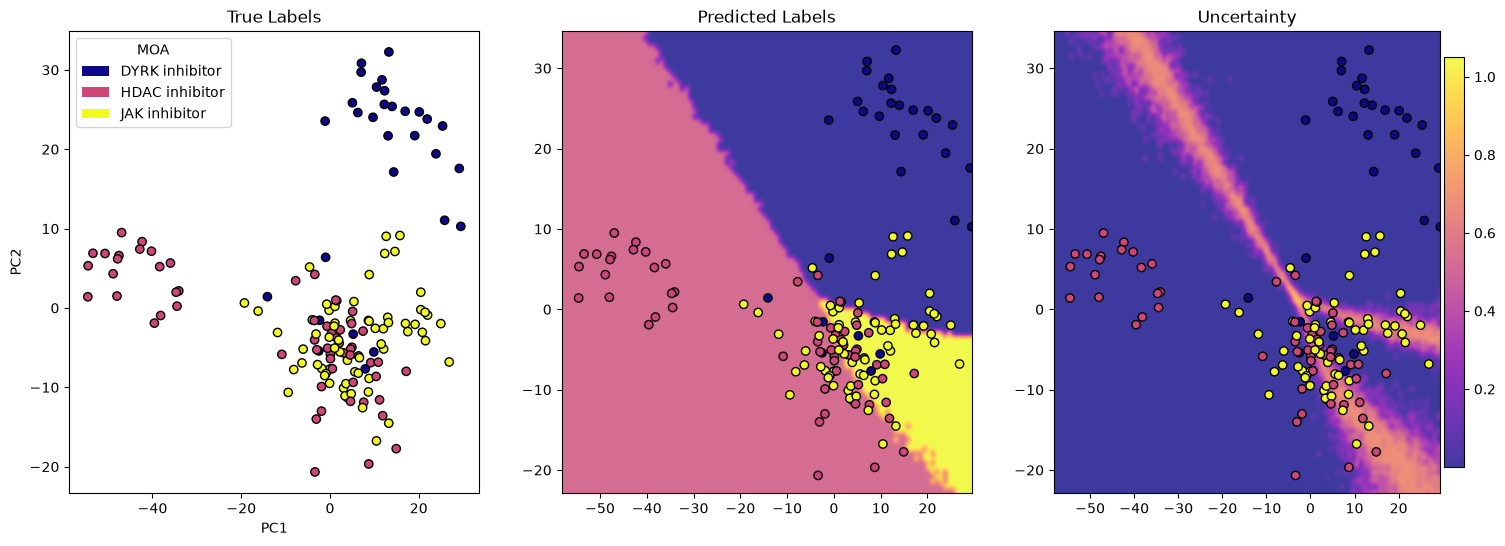

In [34]:
x0_min, x1_min = pc.min(axis=0)[:2]
x0_max, x1_max = pc.max(axis=0)[:2]
xx, yy = np.meshgrid(
            np.linspace(x0_min, x0_max, 100), np.linspace(x1_min, x1_max, 100)
        )
test_grid_points = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).to(
            torch.float32
        )

preds = mc_dropout_module.predict_step(
    torch.tensor(pca.inverse_transform(test_grid_points).astype(np.float32)).to(mc_dropout_module.device)
)

fig = plot_predictions_classification(
    pca.transform(data_module.X_valid), 
    data_module.y_valid, 
    preds["pred"].argmax(-1),
    test_grid_points, 
    preds["pred_uct"]
)

fig.axes[0].set_xlabel("PC1")
fig.axes[0].set_ylabel("PC2")

# Create legend patches for MOA classes
from matplotlib.patches import Patch
moa_classes = data_module.label_encoder.classes_
colors = plt.cm.plasma(np.linspace(0, 1, len(moa_classes)))
patches = [Patch(facecolor=colors[i], label=moa_classes[i]) for i in range(len(moa_classes))]
fig.axes[0].legend(handles=patches, title="MOA", loc="best")